### PhayaThaiBERT(เพิ่ม) + Cross Validation(ต่อ)

In [6]:
import pandas as pd
import torch
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import gc
import seaborn as sns
import matplotlib.pyplot as plt
import os
import shutil

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoConfig,
    TrainingArguments,  
    DataCollatorWithPadding,
    Trainer
)

from datasets import Dataset, DatasetDict, load_from_disk

In [2]:
model_name = "clicknext/phayathaibert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [3]:
full_ds = load_from_disk("../model")
full_ds = full_ds.rename_column("Label", "labels")
print(full_ds)

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 433
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 108
    })
})


In [7]:
labels = np.array(full_ds["train"]["labels"])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X=np.zeros(len(labels)), y=labels)):

    print(f"Fold {fold+1} / 5")

    train_fold = full_ds["train"].select(train_idx)
    val_fold   = full_ds["train"].select(val_idx)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,                   
        num_labels=2,                  
        ignore_mismatched_sizes=True  
    )

    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer,
        return_tensors="pt"
    )

    training_args = TrainingArguments(
        output_dir=f"./phayathaibert_fold_{fold+1}",
        num_train_epochs=4,            
        learning_rate=2e-5,         
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",         
        save_strategy="epoch",         
        load_best_model_at_end=True,     
        metric_for_best_model="eval_f1",  # เลือกตาม F1
        greater_is_better=True,
        logging_steps=10,
        seed=42,
        report_to="none",
        remove_unused_columns=False
        
    )

    
    def compute_metrics(pred):
        labels = pred.label_ids
        preds = np.argmax(pred.predictions, axis=-1)
        return {
        "accuracy": accuracy_score(labels, preds),
            "f1": f1_score(labels, preds, average="binary")            
        }

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_fold,
        eval_dataset=val_fold,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    trainer.train()

    
# Evaluate
    predictions = trainer.predict(val_fold)
    preds = np.argmax(predictions.predictions, axis=-1)
    true_labels = predictions.label_ids

    acc = accuracy_score(true_labels, preds)
    print(f"\n{'='*40}")
    print(f"Fold {fold+1} - Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(
            true_labels, preds,
            target_names=["Normal (0)", "Scam (1)"],
            zero_division=0))
                                
    fold_results.append({
    "fold": fold + 1,
    "accuracy": acc
    })

    mis_idx = np.where(preds != true_labels)[0]

    # Error Analysis
    mis_df = val_fold.select(mis_idx).to_pandas()
    mis_df['pred'] = preds[mis_idx]
    mis_df['true'] = true_labels[mis_idx]

    mis_df['prob'] = np.max(predictions.predictions[mis_idx], axis=1)
    mis_df[['Text', 'true', 'pred', 'prob']].head(20)         

    #Fn and Fp
    fp_exa = (preds == 1) & (true_labels == 0)
    fn_exa = (preds == 0) & (true_labels == 1)

    print(f"False Positives: {fp_exa.sum()}")
    print(f"False Negatives: {fn_exa.sum()}")

                     
# ล้าง memory
    del model, predictions, preds, true_labels, trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()



results_df = pd.DataFrame(fold_results)
print(results_df)
print(f"\nMean Accuracy: {results_df['accuracy'].mean():.2f} +/- {results_df['accuracy'].std():.2f}")

Fold 1 / 5


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3505.44it/s]
[transformers] CamembertForSequenceClassification LOAD REPORT from: clicknext/phayathaibert
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\lenovo\New_Document\Coding\Project AI Builders\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: Us

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.446251,0.296292,0.931034,0.925000
2,0.208224,0.167989,0.954023,0.951220


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.06s/it]
c:\Users\lenovo\New_Document\Coding\Project AI Builders\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  3.00s/it]
c:\Users\lenovo\New_Document\Coding\Project AI Builders\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

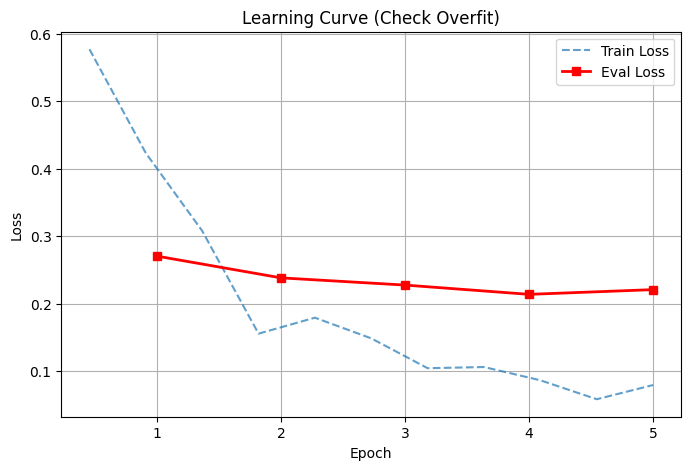

In [8]:
import matplotlib.pyplot as plt

df = pd.DataFrame(trainer.state.log_history)

train = df[df['loss'].notna()]
eval_ = df[df['eval_loss'].notna()]

plt.figure(figsize=(8, 5))
plt.plot(train['epoch'], train['loss'], label='Train Loss', alpha=0.7, linestyle='--')
plt.plot(eval_['epoch'], eval_['eval_loss'], label='Eval Loss', marker='s', color='red', linewidth=2)

plt.title('Learning Curve (Check Overfit)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()